In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

In [2]:
np.random.seed(42)

In [3]:
def generate_datas(n, delta, sigma, dist):
    return dist(0, sigma, n), dist(delta, sigma, n)

In [4]:
def simulate_pvalues(n, delta, sigma, dist, n_sim=1000):
    pvals_tt = []
    pvals_mw = []

    for _ in range(n_sim):
        a, b = generate_datas(n, delta, sigma, dist)

        _, ttp = ttest_ind(a, b, equal_var=False)
        _, mwp = mannwhitneyu(a, b, alternative='two-sided')

        pvals_tt.append(ttp)
        pvals_mw.append(mwp)

    return np.array(pvals_tt), np.array(pvals_mw)

In [5]:
def find_threshold(pvals):
    return np.sum(pvals < 0.05)

In [10]:
sample_sizes = [20, 50, 100, 200, 500]
deltas = [0, 0.1, 0.2, 0.3, 0.4, 0.5]

In [17]:
def simulate(dist):
    size_depends = []
    delta_depends = []

    for n in sample_sizes:
        ttp, mwp = simulate_pvalues(n, 0.3, 0.5, dist)

        size_depends.append((find_threshold(ttp), find_threshold(mwp)))

    for delta in deltas:
        ttp, mwp = simulate_pvalues(100, delta, 0.5, dist)

        delta_depends.append((find_threshold(ttp), find_threshold(mwp)))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(sample_sizes, [data[0] for data in size_depends], marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.title("Мощность t-теста")
    plt.xlabel("Объём выборки")
    plt.ylabel("Мощность")
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(sample_sizes, [data[1] for data in size_depends], marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.title("Мощность критерия Манна-Уитни")
    plt.xlabel("Объём выборки")
    plt.ylabel("Мощность")
    plt.grid(alpha=0.3)

    plt.show()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(deltas, [data[0] for data in delta_depends], marker="o")
    plt.yscale("log")
    plt.title("Мощность t-теста")
    plt.xlabel("Дельта")
    plt.ylabel("Мощность")
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(deltas, [data[1] for data in delta_depends], marker="o")
    plt.yscale("log")
    plt.title("Мощность критерия Манна-Уитни")
    plt.xlabel("Дельта")
    plt.ylabel("Мощность")
    plt.grid(alpha=0.3)

    plt.show()

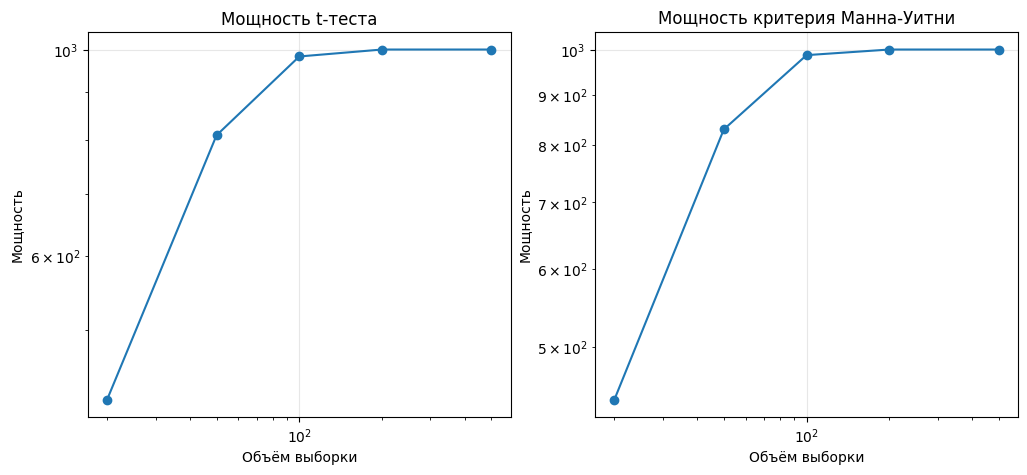

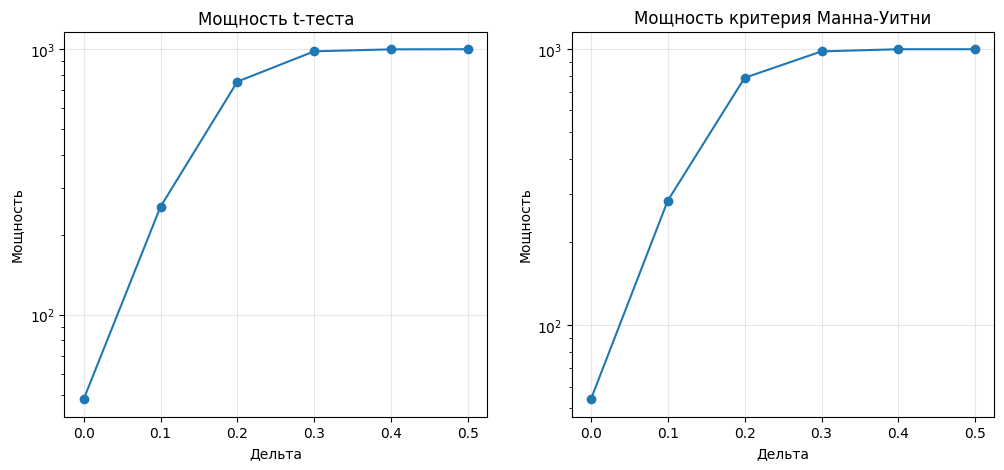

In [18]:
simulate(np.random.lognormal)

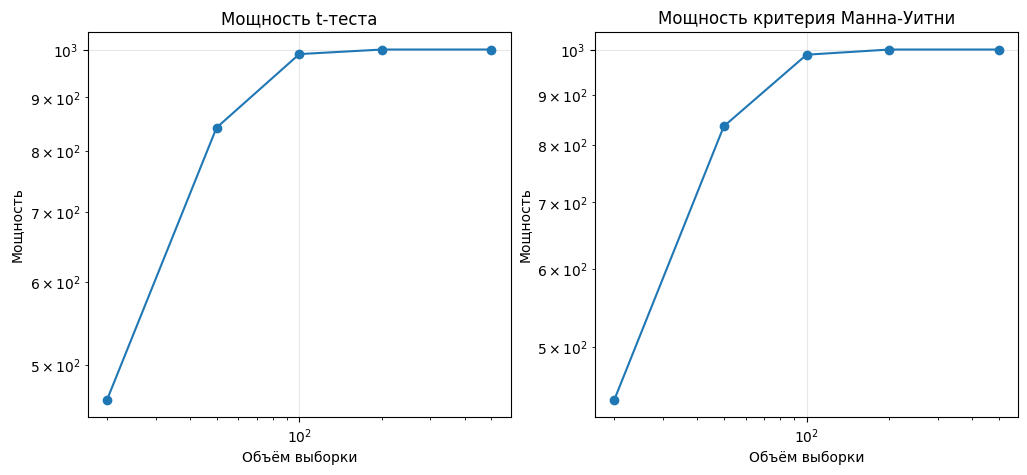

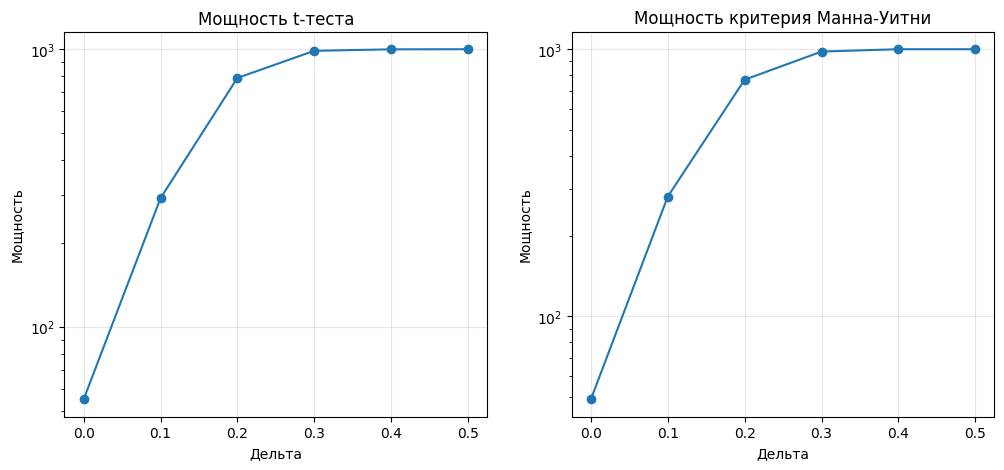

In [19]:
simulate(np.random.normal)